In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# ── Select Feature (X) and Target (y) ─────────────────────────
X = df[['reading score']]    # Input  — must be 2D (double brackets)
y = df['writing score']      # Output — 1D is fine

print("5a) Data Preparation:")
print(f"    Feature (X) : reading score")
print(f"    Target  (y) : writing score")
print(f"    Total rows  : {len(df)}")

# ── Train / Test Split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42
)

print(f"\n    Training samples : {len(X_train)}")
print(f"    Testing  samples : {len(X_test)}")

# ── Train Linear Regression Model ─────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── Model Equation ─────────────────────────────────────────────
slope     = model.coef_[0]
intercept = model.intercept_

print(f"\n    Regression Equation:")
print(f"    Writing Score = {slope:.4f} × Reading Score + ({intercept:.4f})")
print(f"\n    Slope     : {slope:.4f}")
print(f"    Intercept : {intercept:.4f}")

5a) Data Preparation:
    Feature (X) : reading score
    Target  (y) : writing score
    Total rows  : 1000

    Training samples : 800
    Testing  samples : 200

    Regression Equation:
    Writing Score = 0.9971 × Reading Score + (-0.8960)

    Slope     : 0.9971
    Intercept : -0.8960


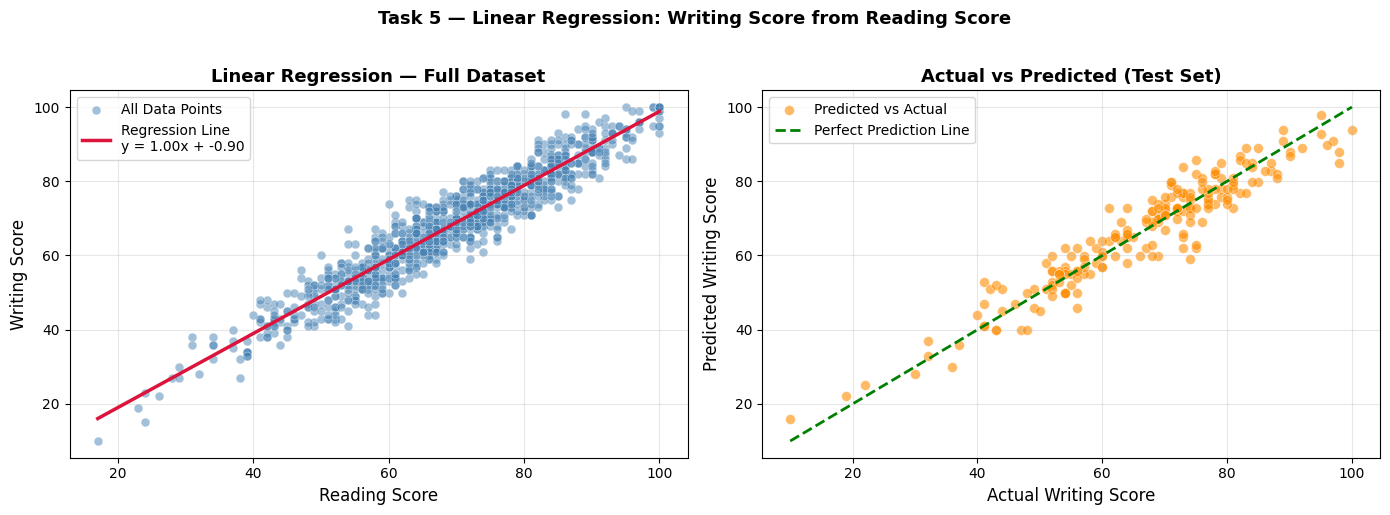

✓ Regression plot saved: task5_regression.png


In [3]:
# ── Make Predictions ───────────────────────────────────────────
y_pred = model.predict(X_test)

# ── Build regression line across full range ────────────────────
x_line = np.linspace(df['reading score'].min(),
                     df['reading score'].max(), 300)
y_line = slope * x_line + intercept

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left Plot: Full Dataset ────────────────────────────────────
axes[0].scatter(df['reading score'], df['writing score'],
                color='steelblue', alpha=0.5, s=40,
                edgecolors='white', linewidth=0.4,
                label='All Data Points')

axes[0].plot(x_line, y_line,
             color='crimson', linewidth=2.5,
             label=f'Regression Line\ny = {slope:.2f}x + {intercept:.2f}')

axes[0].set_xlabel('Reading Score', fontsize=12)
axes[0].set_ylabel('Writing Score', fontsize=12)
axes[0].set_title('Linear Regression — Full Dataset',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Right Plot: Actual vs Predicted (Test Set) ────────────────
axes[1].scatter(y_test, y_pred,
                color='darkorange', alpha=0.6, s=50,
                edgecolors='white', linewidth=0.4,
                label='Predicted vs Actual')

# Perfect prediction line (diagonal)
perfect = np.linspace(y_test.min(), y_test.max(), 100)
axes[1].plot(perfect, perfect,
             color='green', linewidth=2, linestyle='--',
             label='Perfect Prediction Line')

axes[1].set_xlabel('Actual Writing Score', fontsize=12)
axes[1].set_ylabel('Predicted Writing Score', fontsize=12)
axes[1].set_title('Actual vs Predicted (Test Set)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Task 5 — Linear Regression: Writing Score from Reading Score',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task5_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Regression plot saved: task5_regression.png")

In [4]:
# ── R² on Test Set ─────────────────────────────────────────────
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# ── R² on Full Dataset ─────────────────────────────────────────
y_pred_all = model.predict(X)
r2_full    = r2_score(y, y_pred_all)

print("5c) Model Evaluation Metrics:")
print(f"    R² Score  (test set)     : {r2:.4f}  ({r2*100:.2f}%)")
print(f"    R² Score  (full dataset) : {r2_full:.4f}  ({r2_full*100:.2f}%)")
print(f"    MSE                      : {mse:.4f}")
print(f"    RMSE                     : {rmse:.4f}")

5c) Model Evaluation Metrics:
    R² Score  (test set)     : 0.9010  (90.10%)
    R² Score  (full dataset) : 0.9112  (91.12%)
    MSE                      : 23.8704
    RMSE                     : 4.8857


In [5]:
print("5d) R² Interpretation:")
print("=" * 55)
print(f"""
  R² Score = {r2:.4f} ({r2*100:.1f}%)

  ● What R² means:
      R² measures how well the linear regression model fits
      the data. It tells us what percentage of the variance
      in the Writing Score is explained by the Reading Score.

  ● Our Result (R² = {r2:.4f}):
      {r2*100:.1f}% of the variation in Writing Score is
      explained by Reading Score alone.
      Only {(1-r2)*100:.1f}% is due to other factors.

  ● Strength of fit:
      R² >= 0.90  →  Excellent fit  ✅  (our model: {r2:.2f})
      R² >= 0.70  →  Good fit
      R² >= 0.50  →  Moderate fit
      R²  < 0.50  →  Poor fit

  ● Why is R² so high?
      Reading and Writing are closely related language
      skills. Students who read well tend to write well,
      which explains the very strong linear relationship.

  ● Regression Equation:
      Writing Score = {slope:.4f} × Reading Score + {intercept:.4f}

      Example prediction:
      If a student scores 70 in Reading:
      Writing = {slope:.4f} × 70 + {intercept:.4f} = {slope*70+intercept:.2f}
""")

5d) R² Interpretation:

  R² Score = 0.9010 (90.1%)

  ● What R² means:
      R² measures how well the linear regression model fits
      the data. It tells us what percentage of the variance
      in the Writing Score is explained by the Reading Score.

  ● Our Result (R² = 0.9010):
      90.1% of the variation in Writing Score is
      explained by Reading Score alone.
      Only 9.9% is due to other factors.

  ● Strength of fit:
      R² >= 0.90  →  Excellent fit  ✅  (our model: 0.90)
      R² >= 0.70  →  Good fit
      R² >= 0.50  →  Moderate fit
      R²  < 0.50  →  Poor fit

  ● Why is R² so high?
      Reading and Writing are closely related language
      skills. Students who read well tend to write well,
      which explains the very strong linear relationship.

  ● Regression Equation:
      Writing Score = 0.9971 × Reading Score + -0.8960

      Example prediction:
      If a student scores 70 in Reading:
      Writing = 0.9971 × 70 + -0.8960 = 68.90

